# Fetch Historical Data

In [ ]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Fetch historical data from Yahoo Finance
def fetch_data(ticker, period='max'):
    stock = yf.Ticker(ticker)
    data = stock.history(period=period)
    return data

# Example usage
ticker = '^NSEI'
data = fetch_data(ticker)


# Identify Significant Drops

In [ ]:
def identify_drops(data, drop_threshold=0.05):
    data['Daily Return'] = data['Close'].pct_change()
    data['Drop'] = data['Daily Return'] < -drop_threshold

    drop_dates = data.index[data['Drop']]
    return drop_dates


# Visualize the Drops

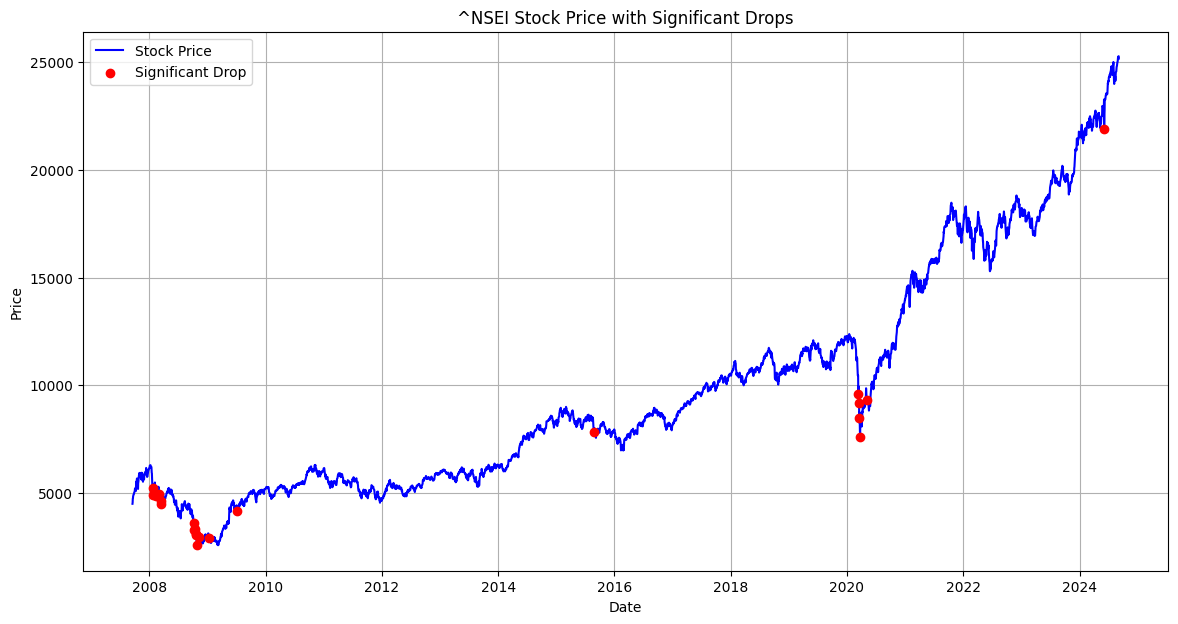

In [ ]:
def plot_drops(data, drop_dates):
    plt.figure(figsize=(14, 7))
    plt.plot(data.index, data['Close'], label='Stock Price', color='blue')

    # Highlight drops
    plt.scatter(drop_dates, data.loc[drop_dates]['Close'], color='red', label='Significant Drop', zorder=5)

    plt.title(f"{ticker} Stock Price with Significant Drops")
    plt.xlabel('Date')
    plt.ylabel('Price')
    plt.legend()
    plt.grid(True)
    plt.show()

# Example usage
plot_drops(data, drop_dates)


# Analyze Patterns

In [ ]:
def analyze_patterns(data, drop_dates, frequency='W'):
    # Create a DataFrame with drop dates
    drop_df = pd.DataFrame(index=drop_dates)
    drop_counts = drop_df.resample(frequency).size()

    return drop_counts

# Example usage
weekly_drops = analyze_patterns(data, drop_dates, frequency='W')
print("Weekly Drop Counts:\n", weekly_drops)


Weekly Drop Counts:
 Date
2008-01-27 00:00:00+05:30    2
2008-02-03 00:00:00+05:30    0
2008-02-10 00:00:00+05:30    0
2008-02-17 00:00:00+05:30    1
2008-02-24 00:00:00+05:30    0
                            ..
2024-05-12 00:00:00+05:30    0
2024-05-19 00:00:00+05:30    0
2024-05-26 00:00:00+05:30    0
2024-06-02 00:00:00+05:30    0
2024-06-09 00:00:00+05:30    1
Freq: W-SUN, Length: 855, dtype: int64


# Predict Future Drops

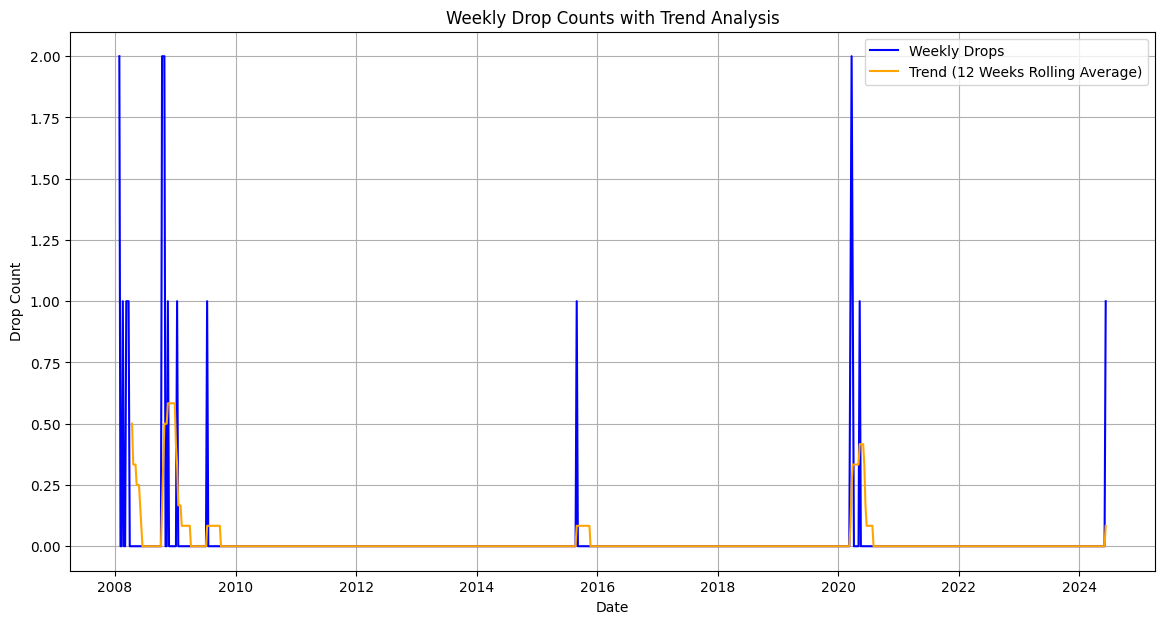

In [ ]:
# Example simple analysis (not predictive modeling)
def simple_trend_analysis(drop_counts):
    return drop_counts.rolling(window=12).mean()

# Example usage
trend = simple_trend_analysis(weekly_drops)
plt.figure(figsize=(14, 7))
plt.plot(weekly_drops.index, weekly_drops, label='Weekly Drops', color='blue')
plt.plot(trend.index, trend, label='Trend (12 Weeks Rolling Average)', color='orange')
plt.title(f"Weekly Drop Counts with Trend Analysis")
plt.xlabel('Date')
plt.ylabel('Drop Count')
plt.legend()
plt.grid(True)
plt.show()


# Full Code

Frequency of Drops (Days):
 Date
1 days       1
2 days       3
4 days       3
5 days       3
10 days      1
18 days      1
20 days      1
21 days      1
42 days      1
57 days      1
180 days     1
203 days     1
1492 days    1
1662 days    1
2240 days    1
Name: count, dtype: int64
Average Period Between Drops: 284 days


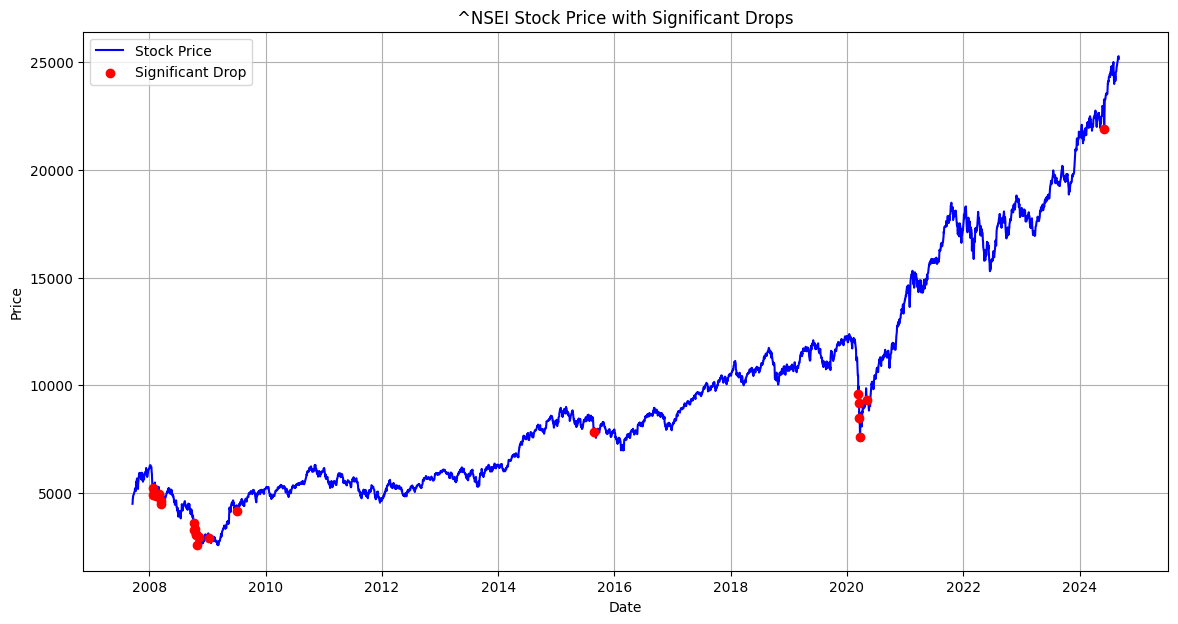

In [ ]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Fetch historical data from Yahoo Finance
def fetch_data(ticker, period='max'):
    stock = yf.Ticker(ticker)
    data = stock.history(period=period)
    return data

# Identify significant drops
def identify_drops(data, drop_threshold=0.05):
    data['Daily Return'] = data['Close'].pct_change()
    data['Drop'] = data['Daily Return'] < -drop_threshold

    drop_dates = data.index[data['Drop']]
    return drop_dates

# Calculate the intervals between drops
def calculate_intervals(drop_dates):
    intervals = drop_dates.to_series().diff().dropna()
    return intervals

# Analyze drop frequency and average period between drops
def analyze_drop_frequency(intervals):
    frequency = intervals.value_counts().sort_index()
    average_period = intervals.mean()
    return frequency, average_period

# Plotting
def plot_drops(data, drop_dates):
    plt.figure(figsize=(14, 7))
    plt.plot(data.index, data['Close'], label='Stock Price', color='blue')

    # Highlight drops
    plt.scatter(drop_dates, data.loc[drop_dates]['Close'], color='red', label='Significant Drop', zorder=5)

    plt.title(f"{ticker} Stock Price with Significant Drops")
    plt.xlabel('Date')
    plt.ylabel('Price')
    plt.legend()
    plt.grid(True)
    plt.show()

# Main code
ticker = '^NSEI'
data = fetch_data(ticker)
drop_dates = identify_drops(data)

# Calculate intervals between drops
intervals = calculate_intervals(drop_dates)

# Analyze and print drop frequency and average period
frequency, average_period = analyze_drop_frequency(intervals)
print("Frequency of Drops (Days):\n", frequency)
print(f"Average Period Between Drops: {average_period.days} days")

# Plot results
plot_drops(data, drop_dates)


# Prediction

In [ ]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.tsa.seasonal import seasonal_decompose

# Fetch historical data from Yahoo Finance
def fetch_data(ticker, period='max'):
    stock = yf.Ticker(ticker)
    data = stock.history(period=period)
    return data

# Identify significant drops
def identify_drops(data, drop_threshold=0.05):
    data['Daily Return'] = data['Close'].pct_change()
    data['Drop'] = data['Daily Return'] < -drop_threshold

    drop_dates = data.index[data['Drop']]
    return drop_dates

# Calculate the intervals between drops
def calculate_intervals(drop_dates):
    if len(drop_dates) < 2:
        return pd.Series()  # Return an empty Series if there are fewer than 2 drops

    intervals = drop_dates.to_series().diff().dropna()
    return intervals

# Predict future drops using basic trend analysis
def predict_future_drops(data, forecast_period=30):
    # Resampling data to daily frequency
    data = data['Close'].resample('D').ffill()

    # Decompose the time series
    decomposition = seasonal_decompose(data, model='additive', period=365)

    # Get trend component
    trend = decomposition.trend.dropna()

    # Generate future dates
    future_dates = pd.date_range(start=data.index[-1] + pd.DateOffset(days=1), periods=forecast_period)

    # Simple prediction based on last known trend value
    future_trend_value = trend.iloc[-1] if not trend.empty else data.iloc[-1]

    future_predictions = pd.Series(index=future_dates, data=future_trend_value)

    return future_dates, future_predictions

# Print significant drops and future predictions
def print_drops_and_predictions(data, drop_dates, future_dates, future_predictions):
    print("Significant Drops:")
    for date in drop_dates:
        print(f"Date: {date.date()}, Price: {data.loc[date]['Close']:.2f}")

    print("\nFuture Predictions:")
    for date, prediction in zip(future_dates, future_predictions):
        print(f"Date: {date.date()}, Predicted Price: {prediction:.2f}")

# Main code
ticker = '^NSEI'
data = fetch_data(ticker)
drop_dates = identify_drops(data)

# Calculate intervals between drops
intervals = calculate_intervals(drop_dates)

# Predict future drops
future_dates, future_predictions = predict_future_drops(data)

# Print significant drops and predictions
print_drops_and_predictions(data, drop_dates, future_dates, future_predictions)



Significant Drops:
Date: 2008-01-21, Price: 5208.80
Date: 2008-01-22, Price: 4899.30
Date: 2008-02-11, Price: 4857.00
Date: 2008-03-03, Price: 4953.00
Date: 2008-03-13, Price: 4623.60
Date: 2008-03-17, Price: 4503.10
Date: 2008-10-06, Price: 3602.35
Date: 2008-10-10, Price: 3279.95
Date: 2008-10-15, Price: 3338.40
Date: 2008-10-17, Price: 3074.35
Date: 2008-10-22, Price: 3065.15
Date: 2008-10-24, Price: 2584.00
Date: 2008-11-11, Price: 2938.65
Date: 2009-01-07, Price: 2920.40
Date: 2009-07-06, Price: 4165.70
Date: 2015-08-24, Price: 7809.00
Date: 2020-03-12, Price: 9590.15
Date: 2020-03-16, Price: 9197.40
Date: 2020-03-18, Price: 8468.80
Date: 2020-03-23, Price: 7610.25
Date: 2020-05-04, Price: 9293.50
Date: 2024-06-04, Price: 21884.50

Future Predictions:
Date: 2024-09-05, Predicted Price: 22014.49
Date: 2024-09-06, Predicted Price: 22014.49
Date: 2024-09-07, Predicted Price: 22014.49
Date: 2024-09-08, Predicted Price: 22014.49
Date: 2024-09-09, Predicted Price: 22014.49
Date: 2024-09